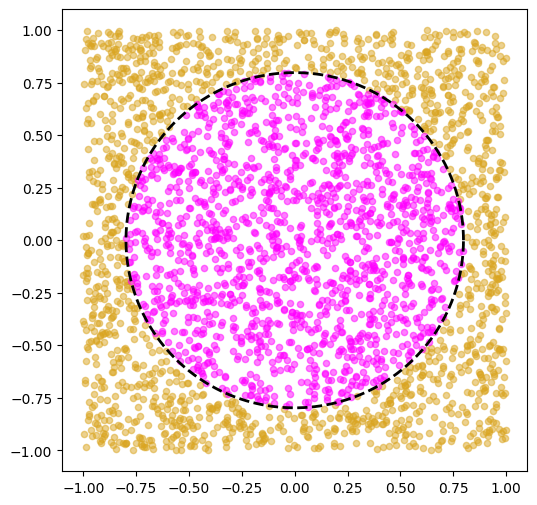

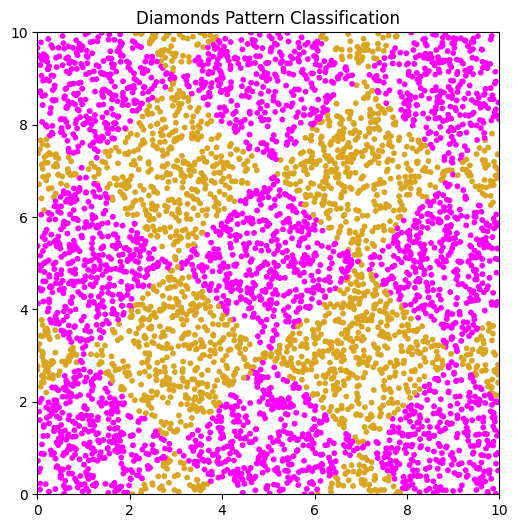

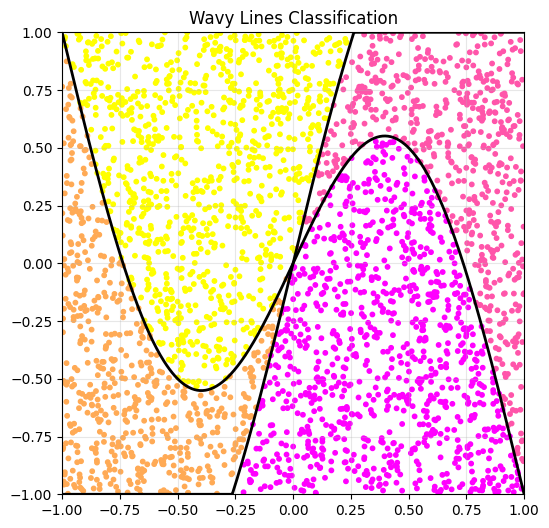

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sys
import warnings
warnings.filterwarnings('ignore') 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from scipy.optimize import minimize

from datasets import circle, plot_circle, diamond, plot_diamond, wavy_lines, plot_wavy
import single_qubit
from single_qubit import *
import importlib
importlib.reload(single_qubit)
import plotting
from plotting import *
importlib.reload(plotting)

import time

# Circle

In [2]:
all_losses_circle = {}
all_train_accuracies_circle = {}
all_test_accuracies_circle = {}

In [11]:
data, (centers, radii) = circle(samples=4200, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.95,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Test: {len(x_test)} samples")

Train/Test datasets
Train: 210 samples
Test: 3990 samples


### 1 layer

In [12]:
n_layers = 1
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)


[[3.13553675 5.85300733 3.66518877]] [[0.53838419 0.45448273 0.20928776]] [0.00371966 0.24150623]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 76.722224
Iteration 2, cost: 74.246972
Iteration 3, cost: 72.306797
Iteration 4, cost: 71.250832
Iteration 5, cost: 68.852206
Iteration 6, cost: 66.988647
Iteration 7, cost: 65.359336
Iteration 8, cost: 63.146715
Iteration 9, cost: 61.846773
Iteration 10, cost: 61.841989
Iteration 11, cost: 61.841948
Iteration 12, cost: 61.841933
Iteration 13, cost: 61.841933
Iteration 14, cost: 61.841933
Iteration 15, cost: 61.841933
[[3.32009438 5.85300634 3.66518896]] [[0.3048967  3.2536763  0.20928776]]
Optimization success: True
Final cost: 61.841933
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [42]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7296


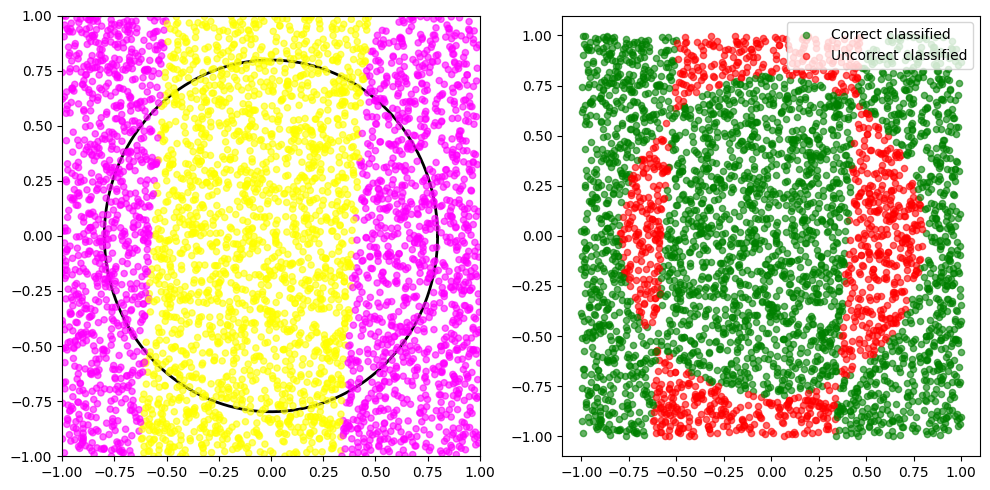

In [43]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 2 layers

In [13]:
n_layers = 2
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[3.20268514 2.38735879 2.8179158 ]
 [6.16159448 2.20082621 2.8411492 ]] [[0.13351555 0.04795773 0.77540951]
 [0.57068318 0.76070481 0.1498628 ]] [0.57182877 0.25364247]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 81.492986
Iteration 2, cost: 76.120477
Iteration 3, cost: 70.285332
Iteration 4, cost: 68.126867
Iteration 5, cost: 66.705453
Iteration 6, cost: 65.931925
Iteration 7, cost: 64.103752
Iteration 8, cost: 62.244902
Iteration 9, cost: 60.779181
Iteration 10, cost: 60.534227
Iteration 11, cost: 60.403962
Iteration 12, cost: 60.333774
Iteration 13, cost: 60.264955
Iteration 14, cost: 60.245135
Iteration 15, cost: 60.230758
Iteration 16, cost: 60.229608
Iteration 17, cost: 60.229117
Iteration 18, cost: 60.229092
Iteration 19, cost: 60.229091
Iteration 20, cost: 60.229091
Iteration 21, cost: 60.229091
Iteration 22, cost: 60.229091
Iteration 23, cost: 60.229091
[[3.22122498 3.005468   2.81791514]
 [6.43123004 2.20082597 3.45925878]] [[ 0.01607928 -0.35417052  0.77540951]
 [

In [14]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7439


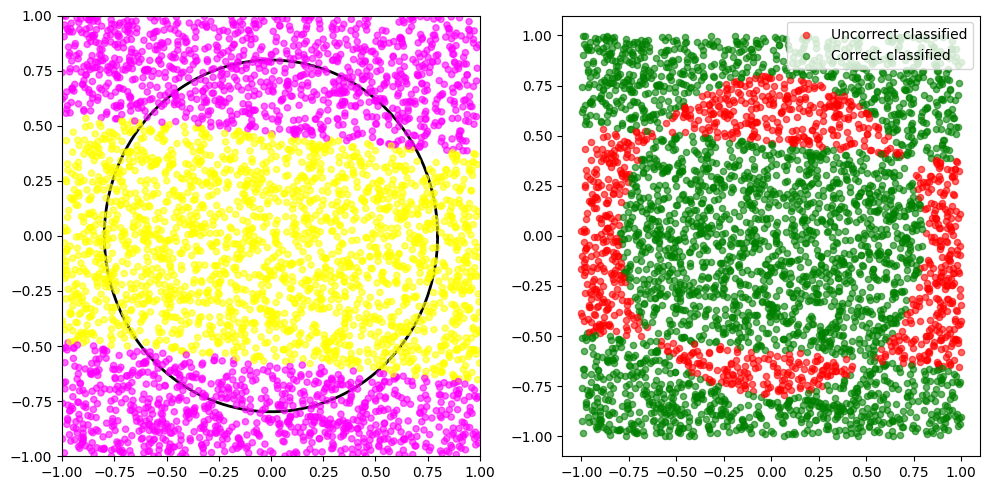

In [15]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 4 layers

In [37]:
#16 min
n_layers = 4
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 200,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[2.82803198 0.13907486 4.02570107]
 [2.60077413 1.69682739 1.29959589]
 [4.10934819 2.61516873 1.12883261]
 [4.32980006 3.55045387 5.39519564]] [[0.1174759  0.7856666  0.67351679]
 [0.11501094 0.69482073 0.44154729]
 [0.94498479 0.14161135 0.64283339]
 [0.38198005 0.95681467 0.3299749 ]] [0.96218591 0.90148585]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 90.504968
Iteration 2, cost: 79.726898
Iteration 3, cost: 66.994274
Iteration 4, cost: 61.781238
Iteration 5, cost: 59.350841
Iteration 6, cost: 57.460426
Iteration 7, cost: 56.133043
Iteration 8, cost: 54.778688
Iteration 9, cost: 54.065218
Iteration 10, cost: 53.849941


KeyboardInterrupt: 

In [14]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.8907


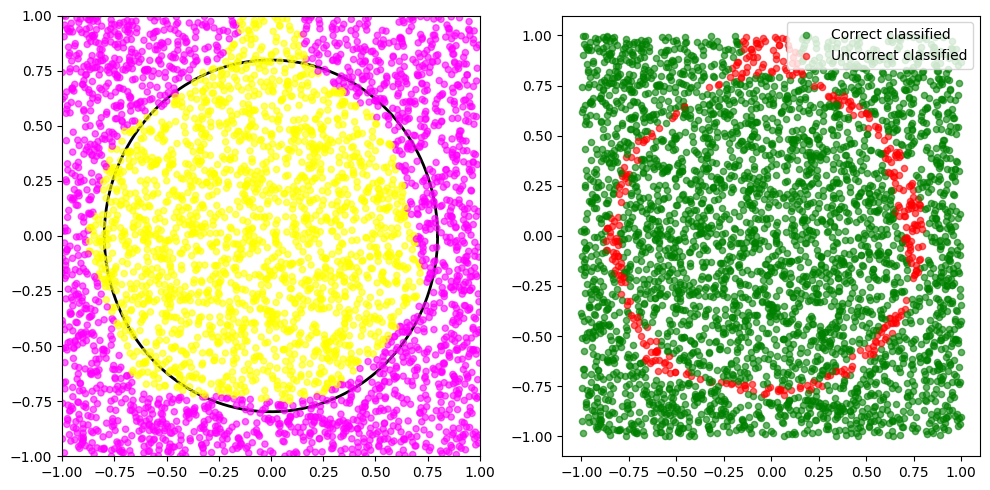

In [23]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 8 layers

In [16]:
# 45 min
n_layers = 8
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[5.48681894 4.42908727 0.53533039]
 [4.08465134 4.10704477 6.00811483]
 [0.01898069 1.55780553 5.82948579]
 [5.85677012 4.527578   4.81143285]
 [0.57480438 3.22877709 1.45507885]
 [1.13862655 5.09128578 0.84846964]
 [2.94462508 5.897261   1.16761724]
 [6.14491391 6.24729566 3.49104554]] [[1.70142740e-01 3.16104888e-01 4.24492833e-01]
 [3.09324224e-01 2.80635580e-01 9.72229709e-01]
 [1.53364827e-01 7.33327909e-01 4.10289439e-04]
 [5.96182669e-01 9.15943004e-01 2.87934094e-01]
 [1.85525975e-01 6.51679795e-01 7.12601407e-01]
 [6.88030519e-01 3.19316880e-01 2.52202402e-01]
 [9.55918800e-01 9.23299508e-01 4.57316610e-01]
 [8.46193866e-01 4.52323478e-01 4.24389018e-01]] [0.15676295 0.42640606]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 88.055538
Iteration 2, cost: 83.455447
Iteration 3, cost: 76.682572
Iteration 4, cost: 74.019189
Iteration 5, cost: 66.321510
Iteration 6, cost: 60.403609
Iteration 7, cost: 54.913720
Iteration 8, cost: 52.262091
Iteration 9, cost: 50.716666
Iterat

In [18]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.9085


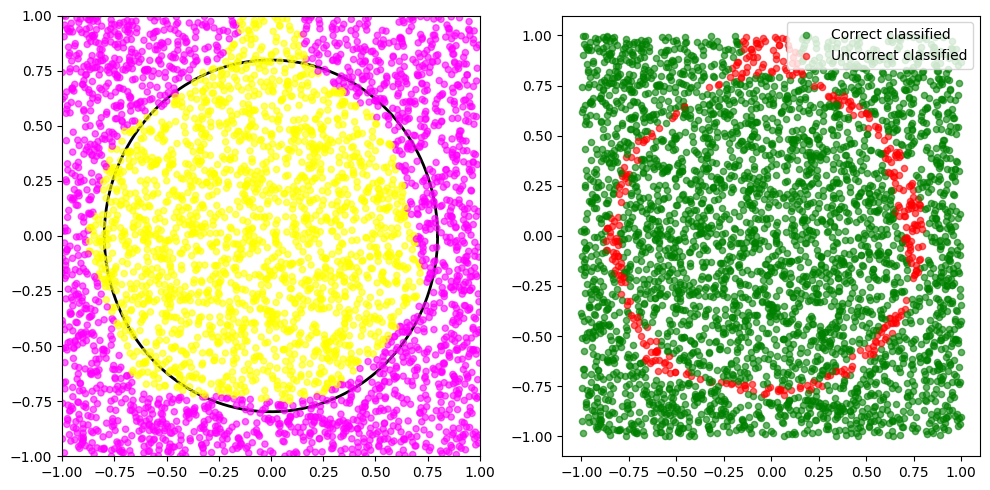

In [21]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 12 layers

In [ ]:
n_layers = 12
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)

theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

In [ ]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 16 layers

In [4]:
start_time = time.time()


n_layers = 16
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 200,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time
                       
if execution_time < 60:
    print(f"⏱️  Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"⏱️  Execution time: {minutes}m {seconds:.2f}s")

[[3.13553675 5.85300733 3.66518877]
 [3.38276761 2.85559923 1.31499379]
 [0.02337132 1.51742838 3.20268514]
 [2.38735879 2.8179158  6.16159448]
 [2.20082621 2.8411492  0.83890295]
 [0.30132732 4.87204167 3.58570814]
 [4.77964926 0.94161574 3.59290613]
 [1.59368267 1.43295466 0.07242008]
 [0.81895492 1.94318885 0.73437091]
 [6.19433127 1.93919612 0.81884951]
 [1.25087106 3.69264829 0.40239733]
 [5.41883345 6.04128066 1.55035977]
 [2.82803198 0.13907486 4.02570107]
 [2.60077413 1.69682739 1.29959589]
 [4.10934819 2.61516873 1.12883261]
 [4.32980006 3.55045387 5.39519564]] [[0.1174759  0.7856666  0.67351679]
 [0.11501094 0.69482073 0.44154729]
 [0.94498479 0.14161135 0.64283339]
 [0.38198005 0.95681467 0.3299749 ]
 [0.96218591 0.90148585 0.27038324]
 [0.80354178 0.9956042  0.252663  ]
 [0.43677717 0.52018074 0.29493114]
 [0.01526484 0.22012924 0.28193688]
 [0.4435997  0.17110248 0.87325436]
 [0.70491113 0.08520048 0.65009245]
 [0.65365648 0.95622117 0.00302087]
 [0.24793245 0.92779148 0.9

In [5]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.9366


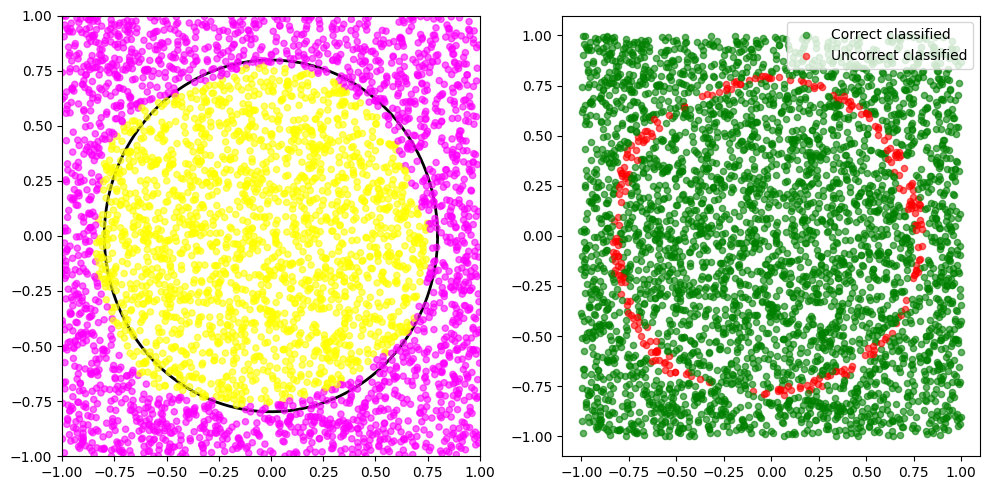

In [6]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

# Wavy Lines

In [4]:
all_losses_wavy = {}
all_train_accuracies_wavy = {}
all_test_accuracies_wavy = {}

In [5]:
data, freq = wavy_lines(samples=4200, freq=1)

x = np.array([i[0] for i in data]) 
y = np.array([i[1] for i in data]) #labels

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Train: {len(x_test)} samples")

Train/Test datasets
Train: 2940 samples
Train: 1260 samples


In [4]:
print(x_train.shape)

(2940, 3)


## 1 layer

In [5]:
start_time = time.time()

n_layers = 1
n_classes = 4

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-6,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_wavy[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_wavy[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time

if execution_time < 60:
    print(f"Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"Execution time: {minutes}m {seconds:.2f}s")

[[5.06235728 0.44995091 1.563971  ]] [[0.81907188 0.80304613 0.94545055]] [0.99754776 0.97627006 0.41013799 0.25032844]
[[ 1.        +0.j          0.        +0.j        ]
 [ 0.57735027+0.j          0.81649658+0.j        ]
 [ 0.57735027+0.j         -0.40824829+0.70710678j]
 [ 0.57735027+0.j         -0.40824829-0.70710678j]]
Iteration 1, cost: 820.229497
Iteration 2, cost: 791.045110
Iteration 3, cost: 775.754084
Iteration 4, cost: 772.010537
Iteration 5, cost: 771.634233
Iteration 6, cost: 771.625660
Iteration 7, cost: 771.625587
[[5.04641847 1.26855617 1.5639709 ]] [[ 1.38892047 -0.05865763  0.94545055]]
Optimization success: True
Final cost: 771.625587
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Execution time: 1m 32.24s


In [6]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_wavy[n_layers] = accuracy

Test accuracy: 0.5667


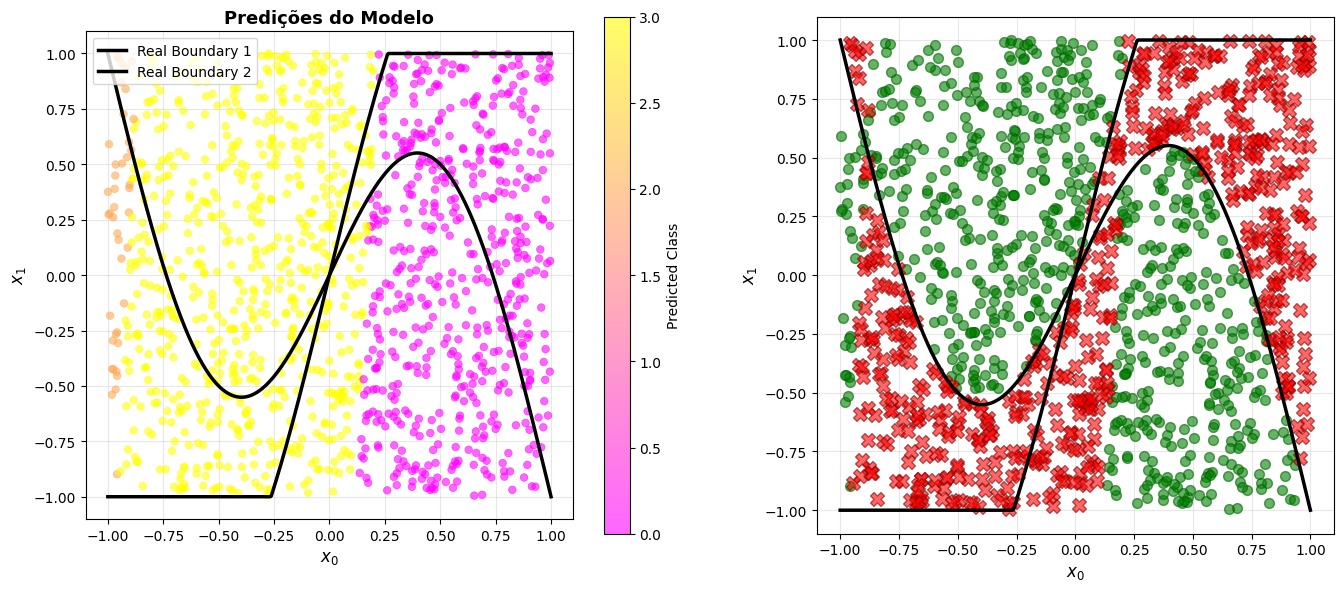

(<Figure size 1400x600 with 3 Axes>,
 array([<Axes: title={'center': 'Predições do Modelo'}, xlabel='$x_0$', ylabel='$x_1$'>,
        <Axes: xlabel='$x_0$', ylabel='$x_1$'>], dtype=object))

In [9]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_wavy(x_test, y_test, preds, freq=1)

## 2 layers

In [6]:
start_time = time.time()

n_layers = 2
n_classes = 4

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_wavy[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_wavy[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time

if execution_time < 60:
    print(f"Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"Execution time: {minutes}m {seconds:.2f}s")

[[0.99685983 3.34175678 1.76883663]
 [0.60471967 2.93398552 3.70776138]] [[0.04690641 0.40209275 0.25766192]
 [0.03065059 0.12566255 0.13903416]] [0.18287425 0.80337757 0.43949187 0.14708599]
[[ 1.        +0.j          0.        +0.j        ]
 [ 0.57735027+0.j          0.81649658+0.j        ]
 [ 0.57735027+0.j         -0.40824829+0.70710678j]
 [ 0.57735027+0.j         -0.40824829-0.70710678j]]
Iteration 1, cost: 1095.613570
Iteration 2, cost: 903.004643
Iteration 3, cost: 866.201475
Iteration 4, cost: 815.279654
Iteration 5, cost: 770.781762
Iteration 6, cost: 716.470656
Iteration 7, cost: 679.894188
Iteration 8, cost: 638.369728
Iteration 9, cost: 566.013126
Iteration 10, cost: 535.488983
Iteration 11, cost: 488.040962
Iteration 12, cost: 457.014545
Iteration 13, cost: 442.802877
Iteration 14, cost: 426.974626
Iteration 15, cost: 417.163219
Iteration 16, cost: 404.538159
Iteration 17, cost: 395.482275
Iteration 18, cost: 386.235536
Iteration 19, cost: 381.697449
Iteration 20, cost: 37

In [7]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_wavy[n_layers] = accuracy

Test accuracy: 0.8738


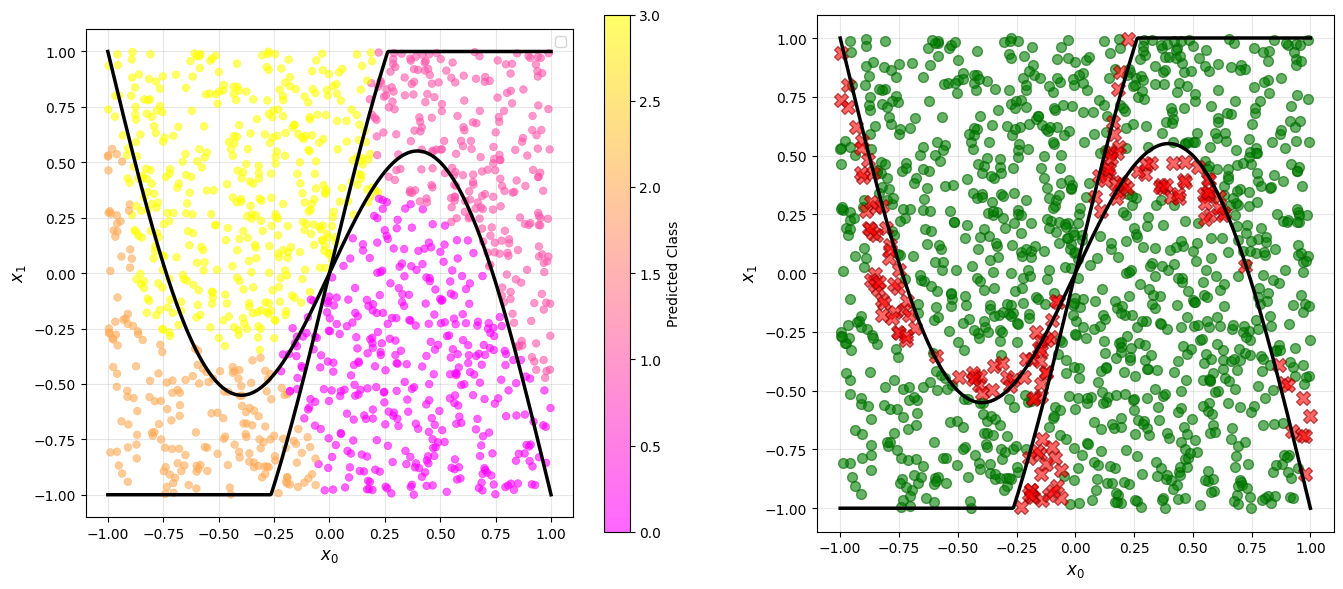

(<Figure size 1400x600 with 3 Axes>,
 array([<Axes: xlabel='$x_0$', ylabel='$x_1$'>,
        <Axes: xlabel='$x_0$', ylabel='$x_1$'>], dtype=object))

In [8]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_wavy(x_test, y_test, preds, freq=1)

## 4 layers

In [10]:
start_time = time.time()

n_layers = 4
n_classes = 4

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-6,
        'gtol': 1e-6,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_wavy[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_wavy[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time

if execution_time < 60:
    print(f"Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"Execution time: {minutes}m {seconds:.2f}s")

[[4.54745318 5.11512235 3.17371494]
 [2.50763144 5.75195059 1.45049565]
 [1.61459062 2.27212744 5.40018275]
 [5.89858063 1.38272623 5.42785622]] [[0.25820296 0.97064125 0.59740789]
 [0.00708647 0.0341299  0.14748453]
 [0.18757316 0.76761912 0.22276588]
 [0.96914162 0.63611206 0.69251751]] [0.21781652 0.89270631 0.66781457 0.86440562]
[[ 1.        +0.j          0.        +0.j        ]
 [ 0.57735027+0.j          0.81649658+0.j        ]
 [ 0.57735027+0.j         -0.40824829+0.70710678j]
 [ 0.57735027+0.j         -0.40824829-0.70710678j]]


KeyboardInterrupt: 

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_wavy[n_layers] = accuracy

## 8 layers

In [ ]:
start_time = time.time()

n_layers = 8
n_classes = 4

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_wavy[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_wavy[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time

if execution_time < 60:
    print(f"Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"Execution time: {minutes}m {seconds:.2f}s")

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_wavy[n_layers] = accuracy

## 12 layers

In [ ]:
start_time = time.time()

n_layers = 12
n_classes = 4

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_wavy[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_wavy[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time

if execution_time < 60:
    print(f"Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"Execution time: {minutes}m {seconds:.2f}s")

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_wavy[n_layers] = accuracy

## 16 layers

In [ ]:
start_time = time.time()

n_layers = 16
n_classes = 4

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_wavy[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_wavy[n_layers] = np.mean(train_preds == y_train)

end_time = time.time()

execution_time = end_time - start_time

if execution_time < 60:
    print(f"Execution time: {execution_time:.2f}s")
else:
    minutes = int(execution_time // 60)
    seconds = execution_time % 60
    print(f"Execution time: {minutes}m {seconds:.2f}s")

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_wavy[n_layers] = accuracy